In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('f1_strategy_dataset_v2.csv')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (52471, 16)
Columns: ['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'Race', 'Year', 'LapTime_Delta', 'Cumulative_Degradation', 'PitStop', 'PitNextLap', 'RaceProgress', 'Normalized_TyreLife', 'Position_Change']


,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


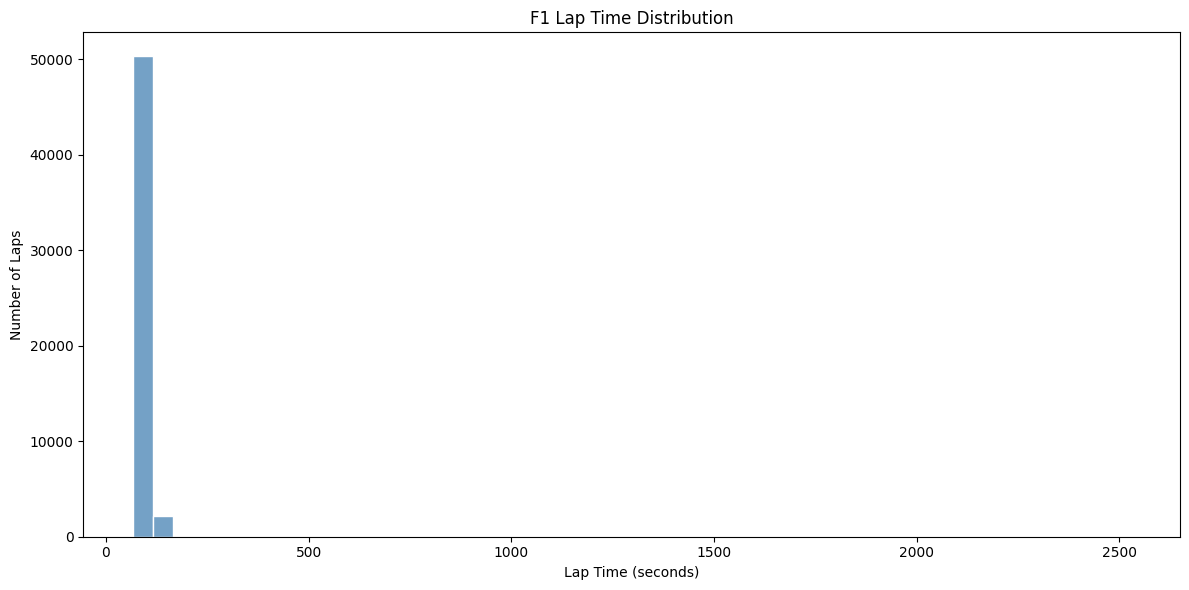

In [7]:
plt.figure(figsize=(12, 6))

sns.histplot(df['LapTime (s)'], bins=50, color='steelblue', edgecolor='white')

plt.title('F1 Lap Time Distribution')
plt.xlabel('Lap Time (seconds)')
plt.ylabel('Number of Laps')

plt.tight_layout()
plt.show()

This chart is telling us there are extreme outliers in the data. The x-axis goes all the way to 2500 seconds — that's over 40 minutes for a single lap, which is impossible in a real race. Those are likely laps where the race was stopped, red flagged, or some data anomaly.
Let's check what those extreme values are and filter them out:

In [24]:
print('Max lap time:', df['LapTime (s)'].max())
print('Min lap time:', df['LapTime (s)'].min())
print()

print('Laps above 200 seconds:', (df['LapTime (s)'] > 200).sum())
print('Laps below 200 seconds:', (df['LapTime (s)'] <= 200).sum())

Max lap time: 2526.253
Min lap time: 67.012

Laps above 200 seconds: 16
Laps below 200 seconds: 52455


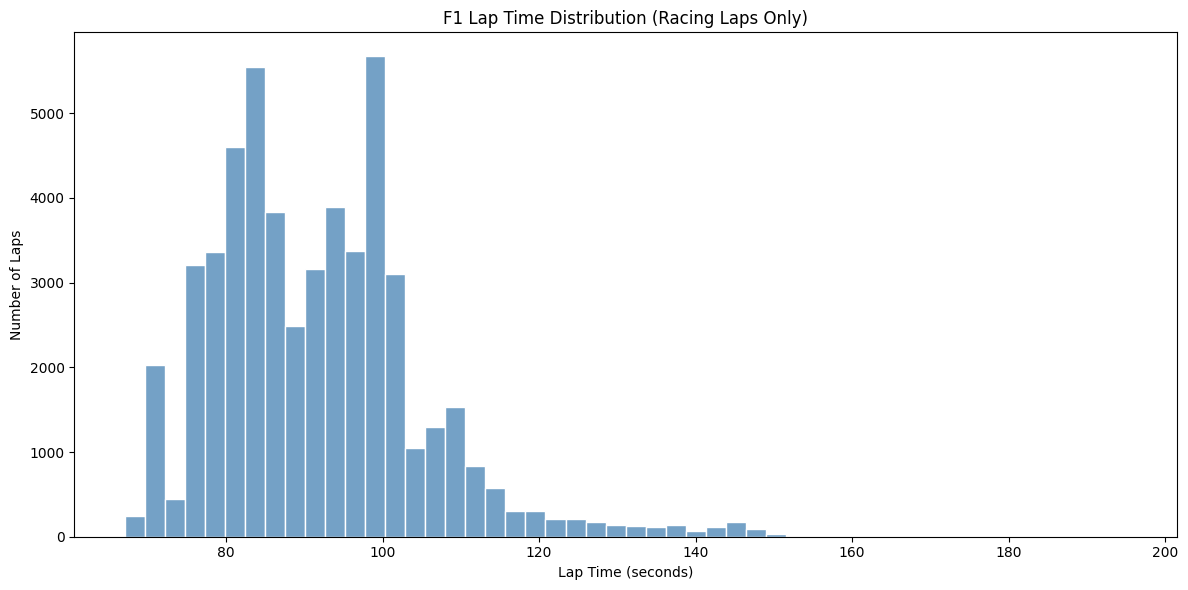

Mean lap time: 91.63 seconds
Fastest lap: 67.01 seconds
Slowest lap: 195.12 seconds


In [25]:
lap_times = df[df['LapTime (s)'] <= 200]['LapTime (s)']

plt.figure(figsize=(12, 6))

sns.histplot(lap_times, bins=50, color='steelblue', edgecolor='white')

plt.title('F1 Lap Time Distribution (Racing Laps Only)')
plt.xlabel('Lap Time (seconds)')
plt.ylabel('Number of Laps')

plt.tight_layout()
plt.show()

print(f'Mean lap time: {lap_times.mean():.2f} seconds')
print(f'Fastest lap: {lap_times.min():.2f} seconds')
print(f'Slowest lap: {lap_times.max():.2f} seconds')

## Lap Time Distribution

The dataset contains 52,471 laps across 25 races from the 2023 and 2024 F1 seasons.
After filtering out 16 extreme outlier laps above 200 seconds, the distribution reveals:

- **Mean lap time:** 91.63 seconds
- **Fastest lap:** 67.01 seconds  
- **Slowest lap:** 195.12 seconds

The distribution shows two distinct peaks — one around 80 seconds and another 
around 95-100 seconds. This suggests the dataset contains races with 
significantly different lap time profiles, creating two clusters rather than 
a single bell curve.

The long tail towards 200 seconds likely represents pit stop laps and laps 
driven under safety car conditions, where drivers slow down significantly.

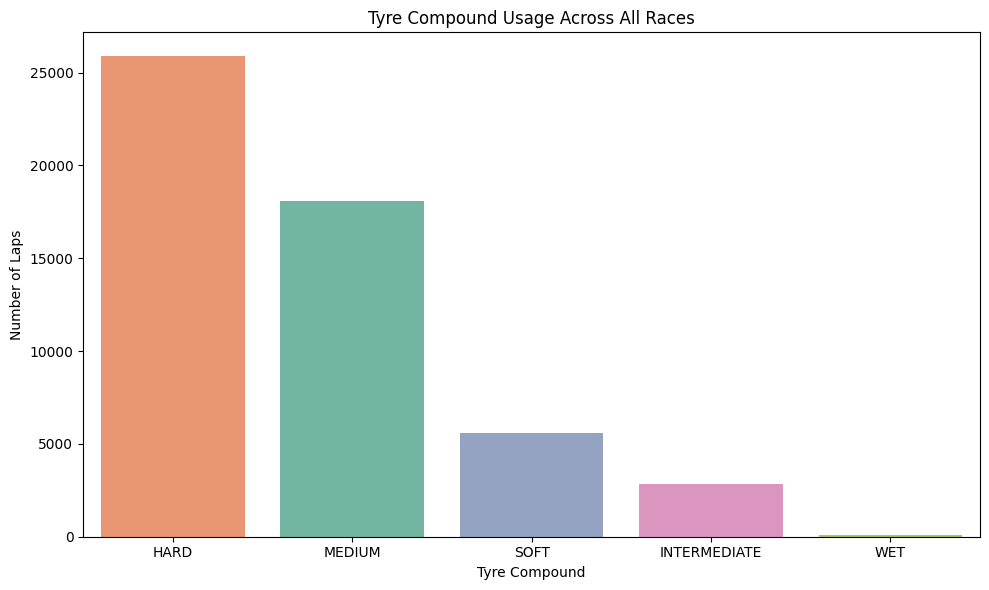

In [10]:
plt.figure(figsize=(10, 6))

compound_order = df['Compound'].value_counts().index

sns.countplot(
    x='Compound',
    data=df,
    hue='Compound',
    palette='Set2',
    legend=False,
    order=compound_order
)

plt.title('Tyre Compound Usage Across All Races')
plt.xlabel('Tyre Compound')
plt.ylabel('Number of Laps')

plt.tight_layout()
plt.show()

## Tyre Compound Usage

Across all 25 races in the dataset, Hard tyres account for the most laps 
(~26,000), followed by Medium (~18,000), Soft (~5,500), Intermediate (~3,000), 
and Wet (minimal usage).

This distribution suggests that Hard and Medium compounds form the backbone 
of race strategy, with drivers spending the majority of their racing laps on 
these two compounds. Soft tyres are used significantly less, suggesting they 
are reserved for shorter stints. Intermediate and Wet compounds appear rarely, 
consistent with the limited number of wet weather races across the two seasons.

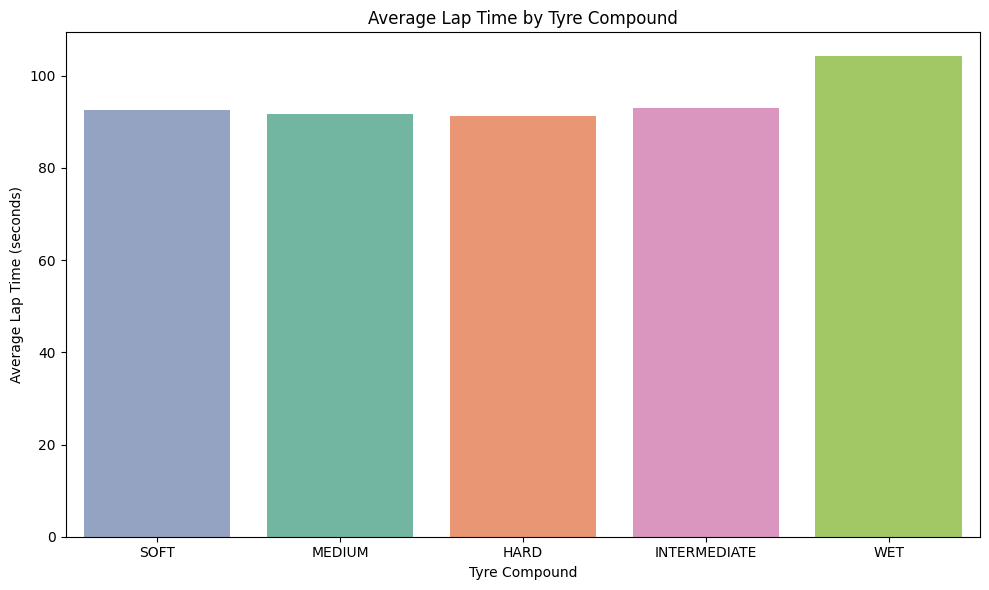

In [ ]:
df_clean = df[df['LapTime (s)'] <= 200]

plt.figure(figsize=(10, 6))

compound_order = ['SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET']

sns.barplot(
    x='Compound',
    y='LapTime (s)',
    data=df_clean,
    estimator=np.mean,
    errorbar=None,
    hue='Compound',
    palette='Set2',
    legend=False,
    order=compound_order
)

plt.title('Average Lap Time by Tyre Compound')
plt.xlabel('Tyre Compound')
plt.ylabel('Average Lap Time (seconds)')

plt.tight_layout()
plt.show()

## Average Lap Time by Tyre Compound

We compare the average lap time recorded on each tyre compound to understand 
whether compound choice has a measurable effect on lap speed.

Soft, Medium and Hard compounds show very similar average lap times — all 
within a 2 second range between 90 and 92 seconds. Wet tyres produce the 
slowest average lap times at approximately 102 seconds.

The minimal difference between dry compounds suggests that other factors 
have a stronger influence on lap time than compound type alone.

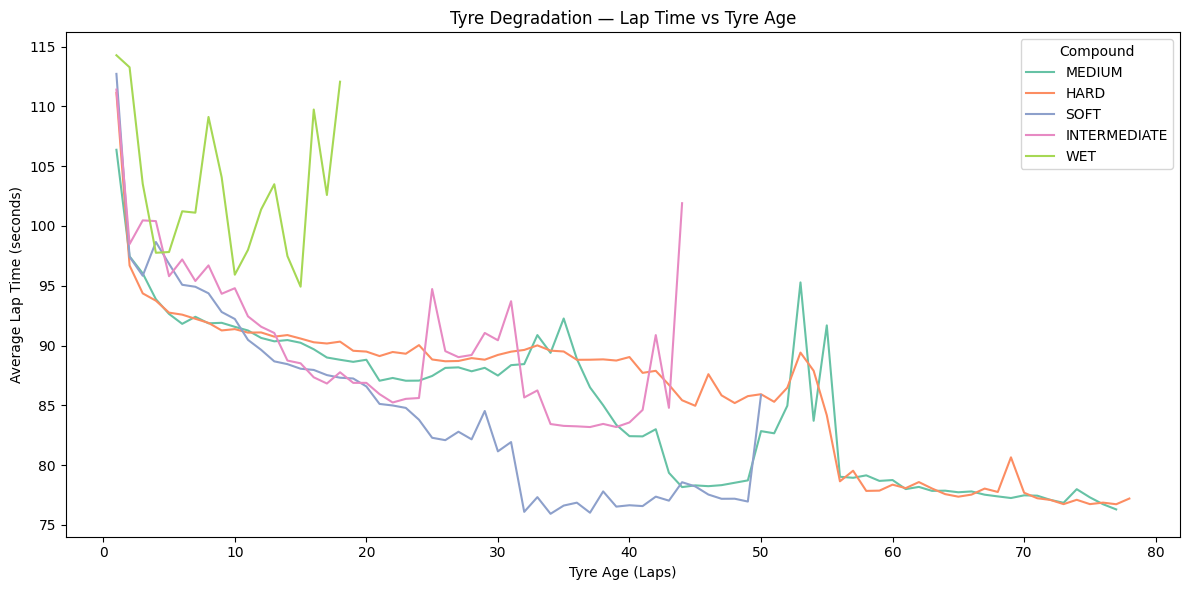

In [19]:
compound_colors = {
	'SOFT': 'red',
    'MEDIUM': 'yellow',
    'HARD': 'white',
    'INTERMEDIATE': 'green',
    'WET': 'blue'
}
df_clean = df[df['LapTime (s)'] <= 200]

plt.figure(figsize=(12, 6))

sns.lineplot(
    x='TyreLife',
    y='LapTime (s)',
    data=df_clean,
    hue='Compound',
    palette='Set2',
    errorbar=None
)

plt.title('Tyre Degradation — Lap Time vs Tyre Age')
plt.xlabel('Tyre Age (Laps)')
plt.ylabel('Average Lap Time (seconds)')

plt.tight_layout()
plt.show()

## Tyre Degradation — Lap Time vs Tyre Age

All three dry compounds (Medium, Hard, Soft) show a consistent pattern — 
lap times are highest in the first 1-5 laps and decrease sharply before 
stabilising. This suggests tyres perform better after an initial warm-up 
period rather than degrading immediately.

After approximately 50 laps on a single set of tyres, the lines become 
increasingly erratic. This is likely due to fewer data points at higher 
tyre ages, as most drivers do not complete 50+ laps on a single set, 
making the averages less reliable at that range.

Wet compound lap times show high variability across all tyre ages, 
reflecting the unpredictable nature of wet race conditions.

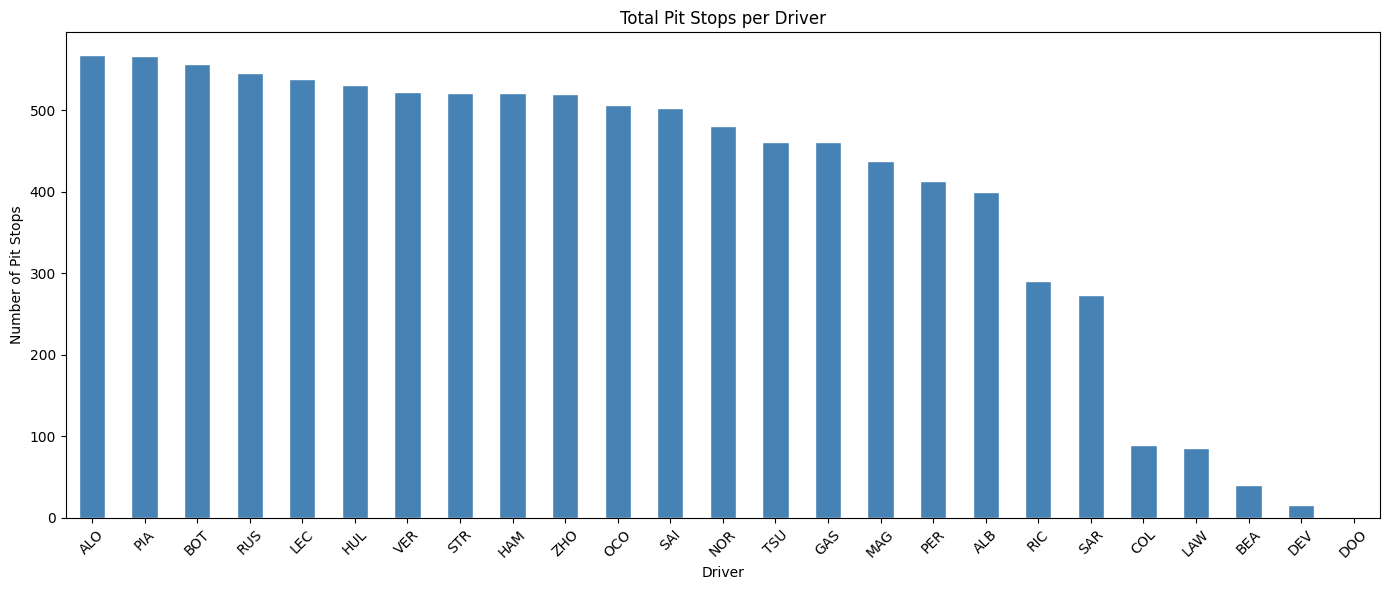

In [21]:
pit_stops = df[df['PitStop'] == 1].groupby('Driver')['PitStop'].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 6))

pit_stops.plot(kind='bar', color='steelblue', edgecolor='white')

plt.title('Total Pit Stops per Driver')
plt.xlabel('Driver')
plt.ylabel('Number of Pit Stops')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Total Pit Stops per Driver

ALO, PIA and BOT recorded the highest total pit stops across the dataset, 
each exceeding 500. Drivers at the lower end — DOO, DEV, BEA, LAW and COL — 
show significantly fewer pit stops, which is consistent with their limited 
number of race appearances in the dataset rather than a difference in 
pit stop strategy.

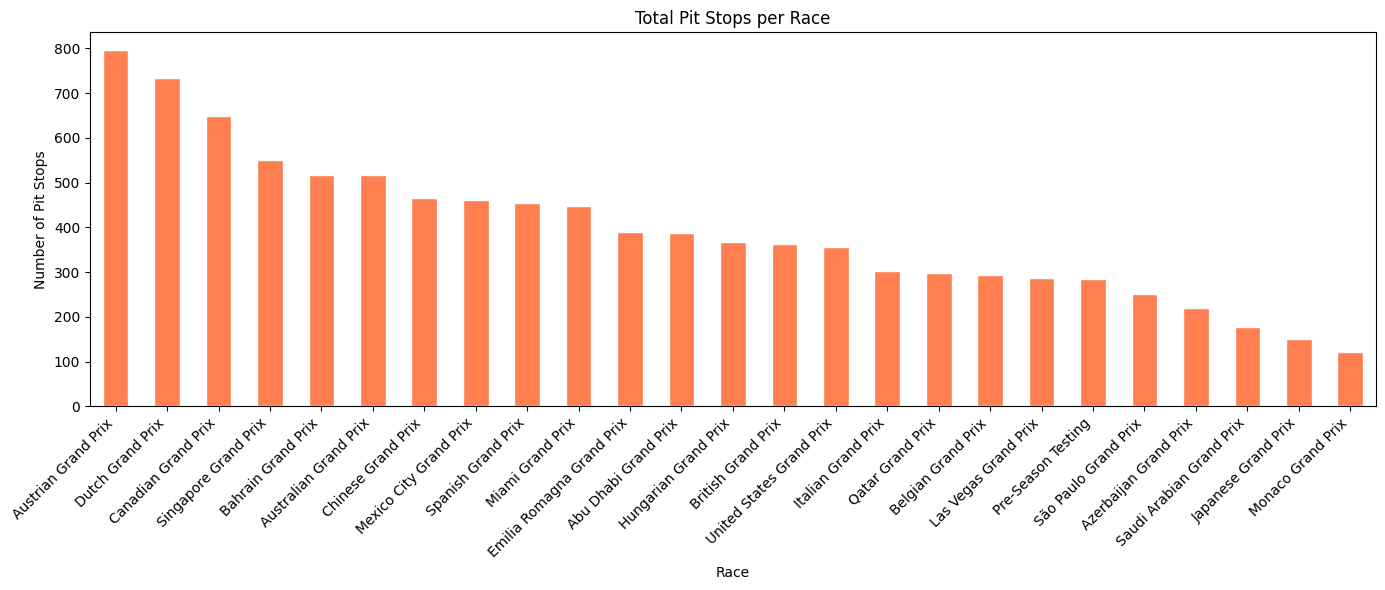

In [22]:
pit_by_race = df[df['PitStop'] == 1].groupby('Race')['PitStop'].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 6))

pit_by_race.plot(kind='bar', color='coral', edgecolor='white')

plt.title('Total Pit Stops per Race')
plt.xlabel('Race')
plt.ylabel('Number of Pit Stops')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Total Pit Stops per Race

The Austrian Grand Prix recorded the highest number of pit stops (~800), 
followed by the Dutch and Canadian Grand Prix. The Monaco Grand Prix had 
the fewest pit stops of any race in the dataset (~110).

Notably, Pre-Season Testing appears in the dataset alongside actual races. 
This is worth keeping in mind as testing sessions follow different rules 
and patterns compared to competitive race events, and may affect any 
race-level analysis.

## Machine Learning — Pit Stop Prediction

Having explored the dataset through EDA, we now move into the machine learning 
phase. The goal is to predict whether a driver will pit on the next lap 
(`PitNextLap`) using race and tyre data available at that point in the race.

This is a binary classification problem — the model predicts either:
- **0** — driver will NOT pit next lap
- **1** — driver WILL pit next lap

### Algorithm: Random Forest Classifier
A Random Forest builds 100 individual decision trees, each trained on a 
slightly different sample of the data. The final prediction is determined 
by majority vote across all trees. This ensemble approach makes Random Forest 
significantly more robust than a single decision tree.

### Features used for prediction
- `Compound` — tyre type currently fitted
- `TyreLife` — how many laps the current tyre has been on
- `Position` — driver's current race position
- `LapTime (s)` — current lap time
- `RaceProgress` — how far through the race the driver is
- `Stint` — which stint of the race the driver is on
- `LapTime_Delta` — change in lap time from previous lap
- `Cumulative_Degradation` — total tyre degradation accumulated

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder


features = ['Compound', 'TyreLife', 'Position', 'LapTime (s)', 
            'RaceProgress', 'Stint', 'LapTime_Delta', 'Cumulative_Degradation']

target = 'PitNextLap'

ml_data = df[df['LapTime (s)'] <= 200][features + [target]].dropna()

le = LabelEncoder()
ml_data = ml_data.copy()
ml_data['Compound'] = le.fit_transform(ml_data['Compound'])

print('Shape:', ml_data.shape)
print('Target distribution:')
print(ml_data['PitNextLap'].value_counts())

Shape: (52455, 9)
Target distribution:
PitNextLap
0    42447
1    10008
Name: count, dtype: int64


## Data Preparation

Before training, we prepare the data for the machine learning model:

- **Features selected:** Compound, TyreLife, Position, LapTime (s), 
RaceProgress, Stint, LapTime_Delta, Cumulative_Degradation
- **Target:** PitNextLap — whether a driver will pit on the next lap (0 or 1)
- **Outlier laps filtered:** Laps above 200 seconds are excluded
- **Encoding:** The Compound column is converted from text to numbers 
using LabelEncoder, as machine learning models only accept numerical input

The prepared dataset contains 52,455 rows with a target distribution of 
approximately 80% non-pit laps (42,447) and 20% pit laps (10,008).

In [27]:
X = ml_data[features]
y = ml_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print('Model trained successfully!')
print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])

Model trained successfully!
Training rows: 41964
Testing rows: 10491


## Data Preparation

The dataset is split into features (X) and target (y). 80% of the data is 
used for training and 20% is held back for testing. The model never sees 
the test data during training, ensuring an honest evaluation of performance.

In [ ]:
# make predictions on test data
y_pred = model.predict(X_test)

# accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print()

print(classification_report(y_test, y_pred))

Accuracy: 0.95

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      8487
           1       0.92      0.82      0.87      2004

    accuracy                           0.95     10491
   macro avg       0.94      0.90      0.92     10491
weighted avg       0.95      0.95      0.95     10491



## Model Evaluation

The trained model is tested against 10,491 rows it has never seen before.

**Overall Accuracy: 95%**

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| 0 — Will not pit | 0.96 | 0.98 | 0.97 | 8,487 |
| 1 — Will pit next lap | 0.92 | 0.82 | 0.87 | 2,004 |

The model performs strongly on both classes. Class 0 (no pit stop) achieves 
an F1-score of 0.97, while Class 1 (pit stop) achieves 0.87.

The slightly lower recall of 0.82 on Class 1 means the model misses 
approximately 18% of actual pit stops. This is expected — pit stops 
represent roughly 20% of all laps, making them the minority class and 
naturally harder to predict than non-pit laps.

The 95% accuracy on a real dataset confirms that the features selected — 
tyre life, lap time delta, race progress and cumulative degradation — 
contain genuine signal for predicting pit stop decisions.

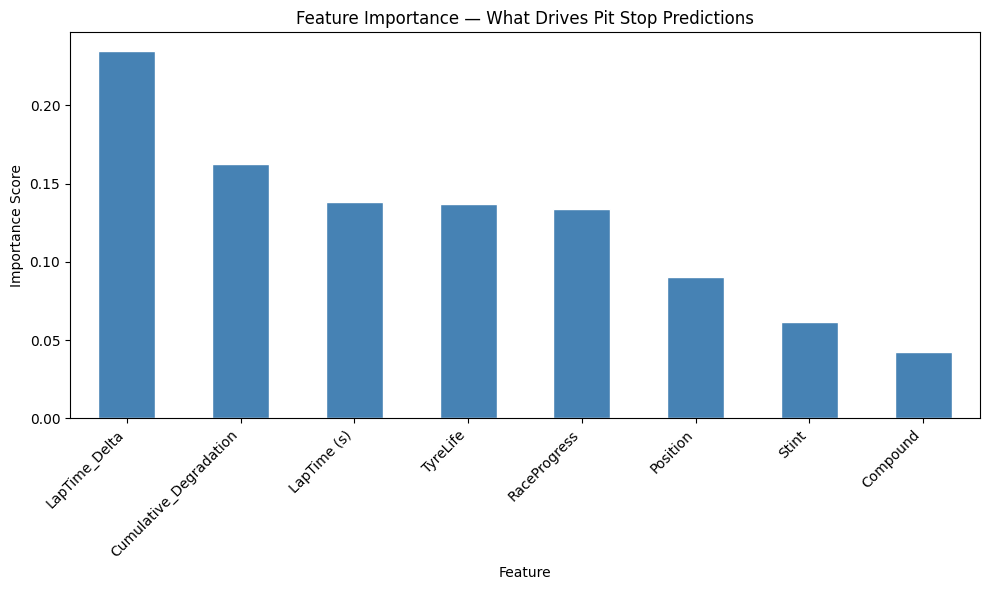

LapTime_Delta             0.234857
Cumulative_Degradation    0.162312
LapTime (s)               0.138070
TyreLife                  0.136698
RaceProgress              0.133765
Position                  0.090622
Stint                     0.061277
Compound                  0.042400
dtype: float64


In [29]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

feature_importance.plot(kind='bar', color='steelblue', edgecolor='white')

plt.title('Feature Importance — What Drives Pit Stop Predictions')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print(feature_importance)

## Feature Importance

The Random Forest model reveals which features contributed most to 
predicting pit stops:

| Feature | Importance Score |
|---|---|
| LapTime_Delta | 0.235 |
| Cumulative_Degradation | 0.162 |
| LapTime (s) | 0.138 |
| TyreLife | 0.137 |
| RaceProgress | 0.133 |
| Position | 0.092 |
| Stint | 0.062 |
| Compound | 0.041 |

LapTime_Delta — the change in lap time from the previous lap — is the 
single strongest predictor of an upcoming pit stop. This suggests that 
increasing lap time variation is a key signal in pit stop decisions.

Cumulative_Degradation and TyreLife are the next strongest predictors, 
indicating that tyre age and wear play a significant role. Compound type 
is the least important feature, contributing only 0.04 to the model's 
decisions.